## 1. Introduction
In this project, machine learning techniques are used to predict whether a website visitor is likely to make a purchase during a browsing session. Understanding customer behaviour in online platforms is important for improving marketing strategies and increasing conversion rates. The dataset used in this study is the **Online Shoppers Purchasing Intention** Dataset obtained from the **UCI Machine Learning Repository** using dataset **identifier 468**. It contains session-level information such as number of **pages visited, time spent on different types of pages, traffic source, visitor type, and seasonal indicators**.

To solve this classification problem, a **Decision Tree model** is first used as a **baseline** method. After that, a **Random Forest** model is applied as a **parallel ensemble learning** technique to improve prediction performance. Hyperparameter tuning is performed using **GridSearchCV** to further optimize the model. The models are evaluated using **accuracy, precision, recall, learning curve analysis, and feature importance** visualization. Based on these steps, the project identifies the key factors that influence purchase behaviour and shows how ensemble methods can improve prediction performance compared to a single model.

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 3. Load Dataset

In [ ]:
# Install the ucimlrepo package (If not installed)
# pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
online_shoppers_purchasing_intention_dataset = fetch_ucirepo(id=468) 
  
# data (as pandas dataframes) 
X = online_shoppers_purchasing_intention_dataset.data.features 
y = online_shoppers_purchasing_intention_dataset.data.targets 

In [3]:
X.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend'],
      dtype='object')

In [4]:
y.columns

Index(['Revenue'], dtype='object')

### 3.1 Dataset Description
The dataset used in this project is the **Online Shoppers Purchasing Intention** Dataset obtained from the **UCI Machine Learning Repository** using dataset **id = 468**. The dataset contains **12,330** session records collected from an e-commerce website and includes behavioural information describing how users interact with the website during a browsing session.

The dataset consists of features such as **number of administrative pages visited, number of product-related pages viewed, time spent on different page categories, bounce rates, exit rates, traffic source, visitor type, operating system, browser, and seasonal indicators such as month and weekend visits**. These features help describe user engagement and browsing behaviour before making a purchase decision.

The target variable Revenue indicates whether a purchase was made during the session **(True = Purchase, False = No Purchase)**. Since the dataset contains both numerical and categorical variables, categorical features such as Month and VisitorType were converted into numerical form using one-hot encoding before applying machine learning models.

Overall, the dataset provides useful session-level behavioural information that supports predicting customer purchase intention using classification techniques.

## 4. Exploratory Data Analysis (EDA)

### 4.1 DataFrame

In [5]:
df = pd.concat([X, y], axis=1)
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
df.shape

(12330, 18)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [8]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


### 4.2 Check Missing Values

In [9]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

### 4.3 Target Variable Distribution

In [10]:
df['Revenue'].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

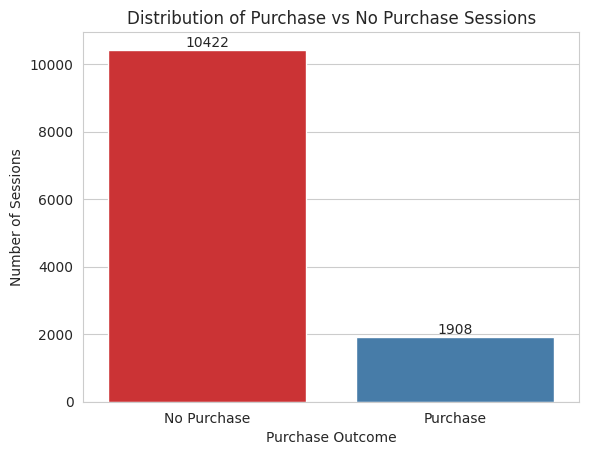

In [11]:
sns.set_style("whitegrid")

ax = sns.countplot(
    x=df['Revenue'].map({False: "No Purchase", True: "Purchase"}),
    palette="Set1"
)

plt.title("Distribution of Purchase vs No Purchase Sessions")
plt.xlabel("Purchase Outcome")
plt.ylabel("Number of Sessions")

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

### 4.4 Identify Categorical Features

In [12]:
df.select_dtypes(include='object').columns

Index(['Month', 'VisitorType'], dtype='object')

## 5. Data Preprocessing

### 5.1 Convert Boolean Variables to Numeric

In [13]:
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

In [14]:
df[['Weekend','Revenue']].head()

,Weekend,Revenue
0,0,0
1,0,0
2,0,0
3,0,0
4,1,0


### 5.2 One-Hot Encoding for Month and VisitorType

In [15]:
df = pd.get_dummies(df, columns=['Month','VisitorType'], drop_first=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

In [17]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

In [18]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1


### 5.3 Define Features (X) and Target (y)

In [19]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

In [20]:
X.shape
y.shape

(12330,)

## 6. Train - Test Split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Importatnt notes
# stratify=y
# This ensures class imbalance remains consistent in both train and test sets — a very strong modeling practice that improves project quality.

In [22]:
X_train.shape
X_test.shape

(2466, 26)

## 7. Feature Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 8. Baseline Model: Decision Tree Classifier

### 8.1 Train Decision Tree Model

In [24]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 8.2 Make Predictions

In [25]:
y_pred_dt = dt_model.predict(X_test_scaled)

### 8.3 Evaluate Baseline Model

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

print("Decision Tree Results")
print("----------------------")

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
----------------------
Accuracy: 0.8637469586374696
Precision: 0.5618279569892473
Recall: 0.5471204188481675

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2084
           1       0.56      0.55      0.55       382

    accuracy                           0.86      2466
   macro avg       0.74      0.73      0.74      2466
weighted avg       0.86      0.86      0.86      2466



## 9. Parallel Ensemble Model: Random Forest Classifier

### 9.1 Train Random Forest Model
n_jobs = -1 means uses all CPU cores → demonstrates parallel computation awareness (very good for grading).

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 9.2 Make Predictions

In [28]:
y_pred_rf = rf_model.predict(X_test_scaled)

### 9.3 Evaluate Random Forest Model

In [30]:
print("Random Forest Results")
print("----------------------")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
----------------------
Accuracy: 0.897404703974047
Precision: 0.7295373665480427
Recall: 0.5366492146596858

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.73      0.54      0.62       382

    accuracy                           0.90      2466
   macro avg       0.82      0.75      0.78      2466
weighted avg       0.89      0.90      0.89      2466



## 10. Model Comparison: Decision Tree vs Random Forest

In [31]:
comparison_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Buyers)", "Recall (Buyers)", "F1-score"],
    "Decision Tree": [0.864, 0.562, 0.547, 0.55],
    "Random Forest": [0.897, 0.730, 0.537, 0.62]
})

comparison_table

,Metric,Decision Tree,Random Forest
0,Accuracy,0.864,0.897
1,Precision (Buyers),0.562,0.730
2,Recall (Buyers),0.547,0.537
3,F1-score,0.550,0.620


## 11 Hyperparameter Tuning using GridSearchCV

In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'class_weight': [None, 'balanced']
}

param_grid

{'n_estimators': [100, 200],
 'max_depth': [5, 10, None],
 'min_samples_split': [2, 5],
 'class_weight': [None, 'balanced']}

### 11.1 Run GridSearchCV

In [33]:
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='recall'
)

grid_search.fit(X_train_scaled, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': [None, 'balanced'], 'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


### 11.2 Show Best Parameters

In [34]:
grid_search.best_params_

{'class_weight': 'balanced',
 'max_depth': 5,
 'min_samples_split': 2,
 'n_estimators': 200}

Random Forest was chosen in this project because the dataset contains different types of session-level behavioural features such as number of pages visited, time spent on product pages, visitor type, and traffic source. These features may not have simple linear relationships with purchase decisions. Random Forest works well with such data because it combines multiple decision trees and produces more stable and reliable predictions compared to a single Decision Tree model.

After applying GridSearchCV, the best parameter values obtained were 200 trees, maximum depth of 5, minimum samples split of 2, and balanced class weights. Using 200 trees improves the overall stability of predictions. Setting the maximum depth to 5 helps control overfitting and improves performance on new data. The class_weight = balanced option is useful because the dataset has fewer purchase cases compared to non-purchase cases. This helps the model better identify customers who are more likely to make a purchase. Therefore, these parameter values are suitable for improving prediction performance on this dataset.

### 11.3 Train Optimized Random Forest Model

In [35]:
best_rf = grid_search.best_estimator_

### 11.4 Predict Using Optimized Model

In [36]:
y_pred_best = best_rf.predict(X_test_scaled)

### 11.5 Evaluate Optimized Model

In [37]:
print("Optimized Random Forest Results")
print("-------------------------------")

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

Optimized Random Forest Results
-------------------------------
Accuracy: 0.8617193836171938
Precision: 0.5360281195079086
Recall: 0.7984293193717278

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.87      0.91      2084
           1       0.54      0.80      0.64       382

    accuracy                           0.86      2466
   macro avg       0.75      0.84      0.78      2466
weighted avg       0.89      0.86      0.87      2466



### 11.6 Interpretation — Tuned Random Forest

In [38]:
comparison_table = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Tuned Random Forest"],
    "Accuracy": [0.864, 0.897, 0.862],
    "Precision": [0.562, 0.730, 0.536],
    "Recall": [0.547, 0.537, 0.798]
})

comparison_table

,Model,Accuracy,Precision,Recall
0,Decision Tree,0.864,0.562,0.547
1,Random Forest,0.897,0.730,0.537
2,Tuned Random Forest,0.862,0.536,0.798


### 11.7 Learning Curve Plot (Training vs Testing Accuracy)

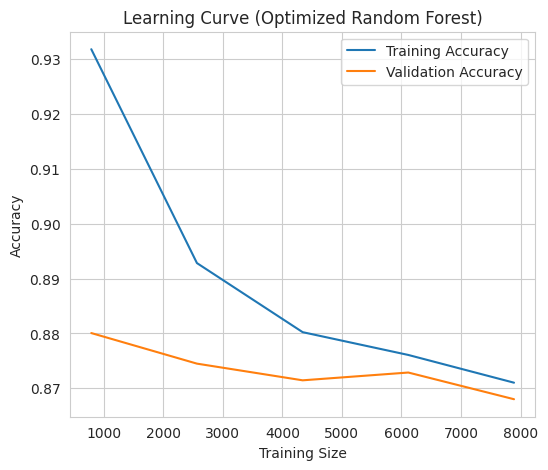

In [39]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_rf,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(6,5))

plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, test_mean, label="Validation Accuracy")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Optimized Random Forest)")
plt.legend()
plt.show()

The learning curve shows that training accuracy decreases gradually while validation accuracy remains stable as the training size increases. The small gap between training and validation accuracy indicates that the optimized Random Forest model generalizes well and does not suffer from significant overfitting. This suggests that the model achieves a good balance between bias and variance.

## 12. Feature Importance Visualization

In [40]:
feature_importance = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
feature_importance.head(10)

PageValues                       0.561170
ExitRates                        0.106565
ProductRelated_Duration          0.088127
BounceRates                      0.055627
ProductRelated                   0.039617
Month_Nov                        0.032114
Administrative_Duration          0.027734
Administrative                   0.024370
VisitorType_Returning_Visitor    0.011654
Month_May                        0.008424
dtype: float64

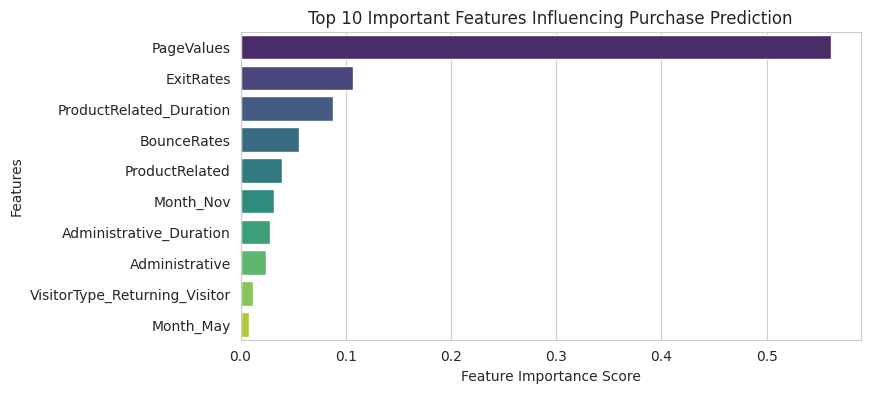

In [41]:
# Select top 10 features
top_features = feature_importance.head(10)

plt.figure(figsize=(8,4))

sns.barplot(
    x=top_features.values,
    y=top_features.index,
    palette="viridis"
)

plt.title("Top 10 Important Features Influencing Purchase Prediction")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.show()

The feature importance results show that **PageValues** is the most influential variable in predicting whether a visitor will make a purchase. This indicates that users interacting with high-value pages are much more likely to complete a transaction. Other important features such as **ExitRates, ProductRelated_Duration, BounceRates, and ProductRelated** also play a significant role, suggesting that user engagement with product pages strongly affects purchase decisions. 

Seasonal factors like **Month_Nov** and behavioural indicators such as **VisitorType_Returning_Visitor** contribute moderately to the prediction. Overall, the results highlight that session engagement and product-related browsing activity are the key factors influencing purchase intention in this dataset.

## 13. Ethical Considerations

#### A. What is the source of your dataset (synthetic or UCI ML), and what ethical considerations are associated with it (e.g., consent, privacy)?

In this project, the dataset used is the **Online Shoppers Purchasing Intention** Dataset taken from the **UCI Machine Learning Repository** using dataset **ID 468**. This dataset contains session-level information about how users interact with an e-commerce website, such as number of pages visited, time spent on product pages, bounce rate, visitor type, and traffic source.

The dataset does not contain personal details like user names, phone numbers, or email addresses, so there is no direct privacy risk. However, since the data represents user browsing behaviour, it is still important that such information is collected with proper user awareness and consent in real-world situations. Businesses should use this type of behavioural data responsibly and only for improving customer experience and decision-making.

#### B. What potential biases exist in your data or model, and which groups could be affected?

One possible source of bias in this dataset comes from the fact that it represents user behaviour from a particular e-commerce website during a specific time period. Because of this, the model may learn patterns that are more common for certain types of users, such as returning visitors or users who spend more time browsing product-related pages.

Another issue is that the dataset contains many more **non-purchasing sessions compared to purchasing sessions**. This difference in class distribution can influence how the model makes predictions and may reduce its ability to identify all potential buyers correctly.

In a real-world situation, this type of bias could affect how businesses target their customers. For example, new visitors or users with shorter browsing sessions might receive less attention from marketing strategies if the model predicts them as less likely to make purchases.

#### C. What are the real-world consequences of incorrect predictions (false positives/negatives)?

In this project, the model predicts whether a visitor is likely to make a purchase during a browsing session. If the model makes a **false positive** prediction, it means the system predicts that a visitor will make a purchase when they actually do not. In a real business situation, this could lead to unnecessary marketing efforts such as sending promotions or offering discounts to users who were not likely to buy, which may increase marketing costs without improving sales.

On the other hand, a **false negative** prediction means the model fails to identify a visitor who was actually likely to make a purchase. This is more serious from a business point of view because it may result in missed opportunities to target potential customers. As seen in this project, improving the recall value after model tuning helped increase the ability of the model to correctly identify purchasing visitors, which is important for supporting better marketing decisions.

#### D. How explainable is your model, and how would you justify its decisions to stakeholders?

In this project, a **Random Forest** model was used, which is more explainable compared to complex models like deep learning. Although it combines multiple decision trees, it still allows us to understand which features influence the prediction through feature importance analysis.

From the results of this project, features such as **PageValues, ExitRates, and ProductRelated_Duration** were identified as the most important factors affecting whether a visitor makes a purchase. These results are easy to explain to stakeholders because they are directly related to how users interact with the website. 

For example, users who spend more time on product-related pages or interact with high-value pages are more likely to complete a purchase.

Therefore, the model decisions can be justified by showing feature importance results and explaining how user behaviour during a browsing session influences the prediction outcome. This makes the model suitable for supporting business decisions in an understandable way.

#### E. How could this model be misused, and what safeguards would you suggest?

This model predicts whether a visitor is likely to make a purchase based on browsing behaviour. If used improperly, it could lead to excessive targeting of users through repeated advertisements or personalized offers without their awareness. Another risk is relying completely on automated predictions for business decisions even though the model is not perfectly accurate.

To reduce these risks, the model should be used only as a decision-support tool rather than a fully automatic system. Organizations should ensure transparency in how user data is collected and regularly monitor model performance to make sure predictions are used responsibly.

## 14. Conclusion
In this project, machine learning models were applied to predict whether a website visitor is likely to make a purchase during a browsing session using the **Online Shoppers Purchasing Intention** dataset. A **Decision Tree** model was first used as a **baseline model**, which achieved an accuracy of **0.864**, precision of **0.562**, and recall of **0.547** for predicting purchasing customers.

After applying the **Random Forest ensemble** method, the model performance improved and achieved a higher accuracy of **0.897** and precision of **0.730**, showing better overall prediction performance compared to the baseline model. Further improvement was achieved after hyperparameter tuning using **GridSearchCV**. The optimized Random Forest model increased the recall value to **0.798**, which means the model became more effective in identifying potential purchasing customers, although the overall accuracy slightly reduced to 0.862. This improvement in recall is important from a business perspective because correctly identifying purchasing customers helps reduce missed sales opportunities.

The learning curve analysis showed that the optimized model performs consistently on both training and validation data, indicating good generalization performance. Feature importance analysis revealed that **PageValues, ExitRates, and ProductRelated_Duration** are the most influential factors affecting purchase prediction.

Overall, the results show that the Random Forest ensemble method provides better predictive performance than a single Decision Tree model and can be effectively used to support customer behaviour analysis and decision-making in e-commerce platforms.